# Iris Clustering using KMeans and PCA

## **Unsupervised Learning Project** ##

This project applies **KMeans clustering** to the Iris dataset and uses **Principal Component Analysis (PCA)** to visualize the clusters in two dimensions.  
The model is trained without using class labels, and PCA is used strictly for visualization.


- ### **Importing libraries** ###

In [18]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from random import randint
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

- ### **Loading data** ###

In [19]:
iris=load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
Centroid_no=5
iterations=100

In [23]:
X1=X
centroids=np.zeros((Centroid_no,X.shape[1]))

- ### **Implementing Kmeans algorithm** ###

In [24]:
for i in range(Centroid_no):
    n=randint(0,X1.shape[0]-1)
    centroids[i]=X1[n]
centroids

array([[ 2.4920192 ,  1.70959465,  1.50164482,  1.05393502],
       [ 1.03800476,  0.09821729,  0.36489628,  0.26414192],
       [-1.50652052,  0.78880759, -1.34022653, -1.18381211],
       [-1.74885626, -0.13197948, -1.39706395, -1.3154443 ],
       [-0.41600969, -1.51316008, -0.03296571, -0.26238682]])

In [25]:
def centroid_find(centroids,X1):
    centroid_map=np.zeros(X1.shape[0],dtype=int)
    for j,entry in enumerate(X1):
        mindist=float("inf")
        for i,centroid in enumerate(centroids):
            dist=(np.sum((entry-centroid)**2))**0.5
            if dist<mindist:
                mindist=dist
                centroid_map[j]=i
    return centroid_map

In [26]:
def new_centroids(X, centroid_map, k):
    d = X.shape[1]
    new_centroid = np.zeros((k, d))
    counts = np.zeros(k)

    for i, entry in enumerate(X):
        idx = centroid_map[i]
        new_centroid[idx] += entry
        counts[idx] += 1

    counts[counts == 0] = 1
    new_centroid = new_centroid / counts[:, np.newaxis]
    return new_centroid

In [27]:
centroid_map=np.zeros(X1.shape[0],dtype=int)
for i in range(iterations):
    print("Iteration ",i)
    print(centroids)
    centroid_map=centroid_find(centroids,X1)
    centroids=new_centroids(X1,centroid_map,Centroid_no)

Iteration  0
[[ 2.4920192   1.70959465  1.50164482  1.05393502]
 [ 1.03800476  0.09821729  0.36489628  0.26414192]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.74885626 -0.13197948 -1.39706395 -1.3154443 ]
 [-0.41600969 -1.51316008 -0.03296571 -0.26238682]]
Iteration  1
[[ 2.15274916  0.88088629  1.49027733  1.34352583]
 [ 0.71247913 -0.17664452  0.7814213   0.80245861]
 [-0.8712079   1.21187191 -1.29414213 -1.23006126]
 [-1.42263507 -0.16739437 -1.33585442 -1.32556985]
 [-0.27753212 -1.25829937  0.194384    0.08079709]]
Iteration  2
[[ 2.11336961  0.38596324  1.52295885  1.2513833 ]
 [ 0.71146761 -0.15148768  0.78106185  0.84421595]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.3996077  -0.05073356 -1.34022653 -1.32318736]
 [-0.24710902 -1.11554748  0.21160746  0.08863234]]
Iteration  3
[[ 1.94676379  0.19413261  1.44007094  1.19653656]
 [ 0.67221496 -0.13632281  0.75096182  0.84034318]
 [-0.78733058  1.36058665 -1.2833891  -1.21778171]
 [-1.38535265  0.02552357 -

- ## **Implementing PCA for visualisation in 2 Dimensions**

In [28]:
pca=PCA(n_components=2)
centroid_pca = pca.fit_transform(centroids)
X_pca=pca.fit_transform(X1)

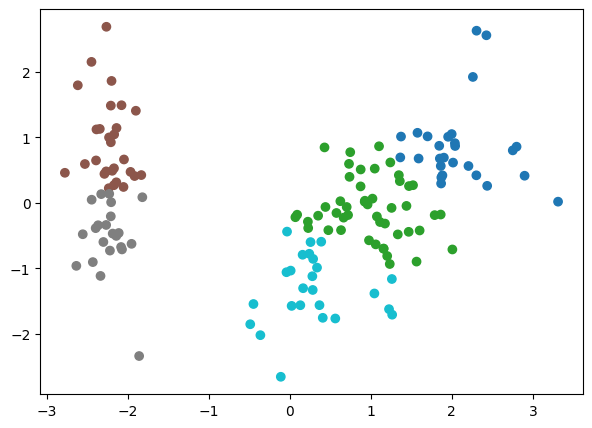

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=centroid_map,
    cmap="tab10",  
)
plt.show()